<link href="https://fonts.googleapis.com/css2?family=Cormorant+Garamond:ital,wght@0,300;1,300&family=Tenor+Sans&display=swap" rel="stylesheet">

<h1 style="font-family: 'Cormorant Garamond', serif; font-size: 80px; font-weight: 300; text-align: center; color: #c9747f; letter-spacing: 2px; line-height: 1.1;">
  MNIST
  <br>
  <em style="font-style: italic; font-size: 96px; color: #e8a4b0; letter-spacing: -2px;">Neural Network</em>
  <br>
  <span style="font-family: 'Tenor Sans', sans-serif; font-size: 13px; font-weight: 400; letter-spacing: 8px; color: #d4a0aa; text-transform: uppercase; display: block; margin-top: 12px;">✦ Handwritten digit recognition ✦</span>
</h1>

<img src="https://mint.westdri.ca/ai/pt/img/mnist_nn.png" style="max-width: 600px; width: 100%; border-radius: 40% 40% 50% 50% / 30% 30% 50% 50%; display: block; margin: 0 auto;" alt="MNIST Neural Network"/>

In [1]:
# Import required libraries
import numpy as np
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
# Load the MNIST dataset (handwritten digits 0–9)
# Dataset is already split into training and testing sets

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Check number of training images

len(X_train)

60000

In [4]:
# Check number of testing images

len(X_test)

10000

In [5]:
# Check shape of training data (60000 images, each 28x28 pixels)

X_train.shape

(60000, 28, 28)

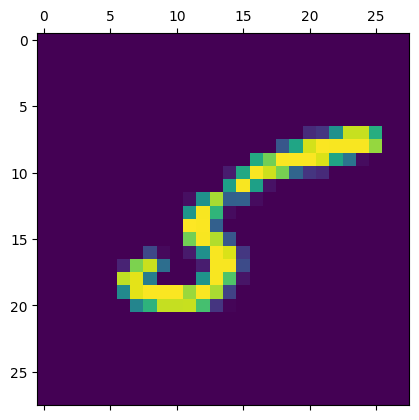

In [6]:
# Display an example image from the dataset

plt.matshow(X_train[11])

In [7]:
# Display the label of that image

y_train[11]

np.uint8(5)

In [8]:
# Normalize pixel values (convert 0–255 → 0–1)
# This helps the neural network train faster

X_train = X_train/255
X_test = X_test/255

In [9]:
# Flatten 28x28 images into 1D vector of 784 values
# Neural networks require 1D input

X_Train_flat = X_train.reshape(len(X_train),28*28)
X_Test_flat = X_test.reshape(len(X_test),28*28)

# View flattened image data

X_Train_flat[1]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [10]:
# Build neural network model

model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])

# Compile the model

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model using training data

model.fit(X_Train_flat, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8048 - loss: 0.7385
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9164 - loss: 0.3044
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9196 - loss: 0.2866
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9239 - loss: 0.2740
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9252 - loss: 0.2656


In [11]:
# Evaluate model performance on test data

model.evaluate(X_Test_flat, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9152 - loss: 0.3036


[0.26836270093917847, 0.9247000217437744]

In [12]:
# Predict probabilities for each class

y_pred = model.predict(X_Test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


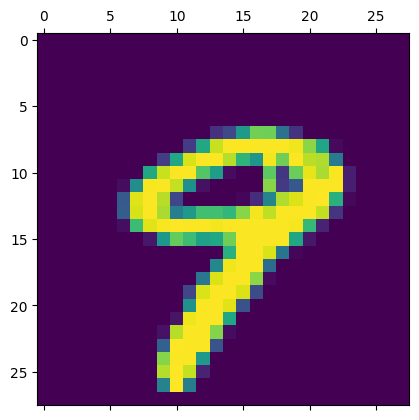

In [13]:
# Show one test image

plt.matshow(X_test[9])

In [14]:
# Show predicted probabilities for image 9

y_pred[9]

array([1.2582753e-04, 5.0197308e-08, 6.5172258e-06, 5.0897582e-04,
       8.5005772e-01, 1.9781853e-03, 1.0119340e-05, 9.2512506e-01,
       2.3100902e-01, 9.9624884e-01], dtype=float32)

In [15]:
# Get index of highest probability (predicted digit)

np.argmax(y_pred)

np.int64(90600)

In [16]:
# Convert all predictions to class labels

y_predicted_labels = [np.argmax(i) for i in y_pred]

# Create confusion matrix

cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

In [17]:
y_test[:7]

array([7, 2, 1, 0, 4, 1, 4], dtype=uint8)

Text(95.72222222222221, 0.5, 'Truth')

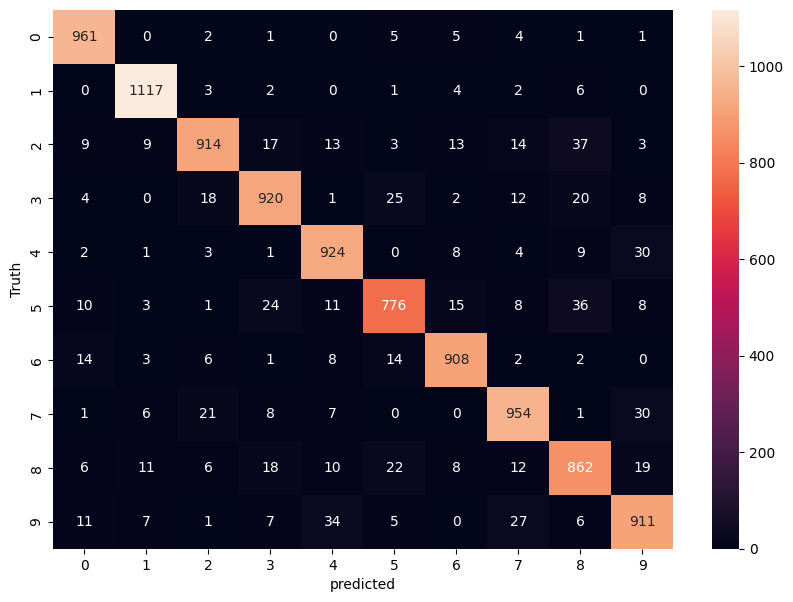

In [18]:
# Plot confusion matrix as heatmap

plt.figure(figsize = (10,7))
sns.heatmap(cm,annot = True, fmt = 'd')
plt.xlabel('predicted')
plt.ylabel('Truth')

In [19]:
# Build improved model with hidden layer

model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation = 'sigmoid')
])

# Compile improved model

model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy']
             )

# Train improved model

model.fit(X_Train_flat, y_train, epochs = 5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8747 - loss: 0.4518
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9611 - loss: 0.1323
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9746 - loss: 0.0851
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9805 - loss: 0.0638
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9853 - loss: 0.0489


In [20]:
# Evaluate improved model accuracy

model.evaluate(X_Test_flat,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9733 - loss: 0.0927


[0.07664988189935684, 0.9765999913215637]

In [21]:
y_pred = model.predict(X_Test_flat)

# convert probability predictions to labels

y_predicted_labels = [np.argmax(i) for i in y_pred]

# create confusion matrix

cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Text(95.72222222222221, 0.5, 'Truth')

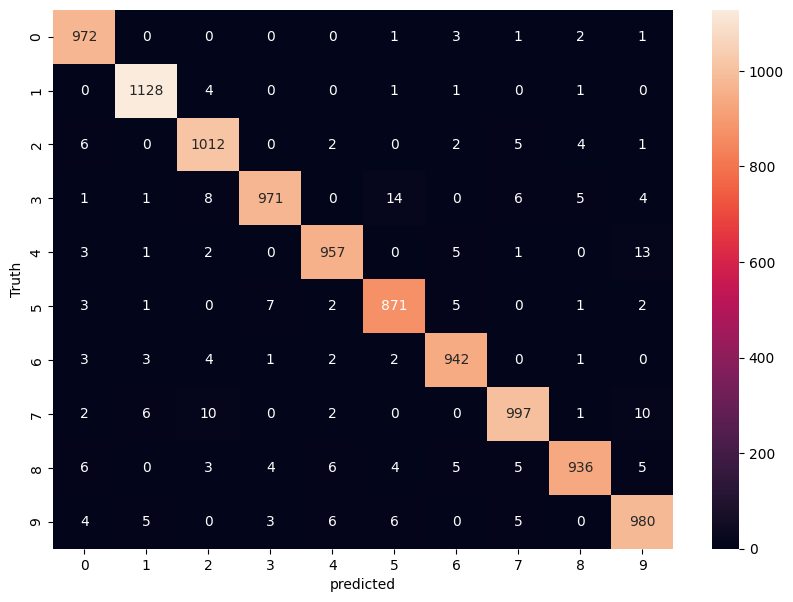

In [22]:
# plot heatmap

plt.figure(figsize = (10,7))
sns.heatmap(cm,annot = True, fmt = 'd')
plt.xlabel('predicted')
plt.ylabel('Truth')

<div style="text-align: center; font-family: 'Cormorant Garamond', serif; padding: 40px 20px;">
  <div style="background: #fff5f7; border-radius: 60% 60% 50% 50% / 40% 40% 60% 60%; display: inline-block; padding: 40px 70px;">
    <p style="font-family: 'Tenor Sans', sans-serif; font-size: 11px; letter-spacing: 6px; color: #d4a0aa; text-transform: uppercase; margin-bottom: 16px;">✦ end of notebook ✦</p>
    <p style="font-size: 42px; font-weight: 300; color: #c9747f; line-height: 1.1;">Thank you ૮ ˶ᵔ ᵕ ᵔ˶ ა </p>
    <em style="font-size: 64px; font-weight: 300; color: #e8a4b0; letter-spacing: -1px; display: block; margin-top: 8px;">Akisha Bhujel</em>
    <p style="font-family: 'Tenor Sans', sans-serif; font-size: 11px; letter-spacing: 5px; color: #d4a0aa; text-transform: uppercase; margin-top: 20px;">✦ 2026 ✦</p>
  </div>
</div>